In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV

In [22]:
import os
import sys
from pathlib import Path
import subprocess

# Ensure project root is importable when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(project_root)

# Install required runtime dependencies in the active notebook kernel
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels", "python-dotenv"])

from dotenv import load_dotenv
load_dotenv(project_root / ".env")

from src.data.data_loader import DataLoader
dl = DataLoader()

C:\GitHub\global-stock-index-ml-classification


In [23]:
dl = DataLoader()
X, y = dl.prepare_X_y()
X.head()

,Volume,LowProportion,HighProportion,Delta Close_(t-1),Delta Close_(t-2),Delta Close_(t-3),Delta Close_(t-4),Delta Close_(t-6),Delta Close_(t-7),Delta Close_(t-8),Delta Close_(t-9),Delta Close_(t-11),Delta Close_(t-14),Delta Close_(t-15),Delta Close_(t-16),Delta Close_(t-21),Delta Close_(t-22),Delta Close_(t-23),Delta Close_(t-29)
Date,,,,,,,,,,,,,,,,,,,
2003-02-24,1.219200e+09,0.983069,1.000054,-24.629883,23.699707,-74.890136,33.700195,80.040039,-55.439941,-83.060059,-4.970215,-94.199707,-44.220215,100.359863,2.720215,-82.790039,-20.619629,-145.529786,-0.830078
2003-02-25,1.495500e+09,0.982515,1.002097,-73.790039,-24.629883,23.699707,-74.890136,152.479980,80.040039,-55.439941,-83.060059,-24.540039,-76.930176,-44.220215,100.359863,-208.700195,-82.790039,-20.619629,23.860351
2003-02-26,1.382300e+09,0.986621,1.000000,-52.240235,-73.790039,-24.629883,23.699707,33.700195,152.479980,80.040039,-55.439941,-4.970215,-67.170410,-76.930176,-44.220215,-39.199707,-208.700195,-82.790039,-37.759766
2003-02-27,1.297100e+09,0.998593,1.012544,-19.840332,-52.240235,-73.790039,-24.629883,-74.890136,33.700195,152.479980,80.040039,-83.060059,-94.199707,-67.170410,-76.930176,78.979981,-39.199707,-208.700195,-68.390136
2003-02-28,1.311700e+09,1.000000,1.010189,62.069824,-19.840332,-52.240235,-73.790039,23.699707,-74.890136,33.700195,152.479980,-55.439941,-24.540039,-94.199707,-67.170410,-56.540039,78.979981,-39.199707,-62.940429


In [24]:
y.head()

Date
2003-02-24    0
2003-02-25    0
2003-02-26    0
2003-02-27    1
2003-02-28    1
dtype: int64

In [25]:
val_size = 0.2
X_train, X_test = DataLoader.time_split_2D(X)
#TODO remove - validation to be done with CV
X_train, X_val = DataLoader.time_split_2D(X_train)
y_train, y_test = DataLoader.time_split_1D(y)
#TODO remove - validation to be done with CV
y_train, y_val = DataLoader.time_split_1D(y_train)

In [26]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5) 

In [27]:
rf = RandomForestClassifier(random_state=42)

In [28]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_log_loss',
    refit=True, # Refit an estimator using the best found parameters on the whole dataset
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [29]:
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: -0.5734521569645364


In [34]:
best_rf = grid_search.best_estimator_

In [35]:
#rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
#rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_val)
y_prob = best_rf.predict_proba(X_val)[:,1]



In [36]:
print("Random Forest Accuracy:", best_rf.score(X_val, y_val))
print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

Random Forest Accuracy: 0.6847826086956522
              precision    recall  f1-score   support

           0       0.70      0.56      0.62       340
           1       0.68      0.80      0.73       396

    accuracy                           0.68       736
   macro avg       0.69      0.68      0.68       736
weighted avg       0.69      0.68      0.68       736

ROC-AUC: 0.754879679144385


In [37]:
y_pred_train = best_rf.predict(X_train)
y_prob_train = best_rf.predict_proba(X_train)[:,1]
print("Random Forest Accuracy:", best_rf.score(X_train, y_train))
print(classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_train))

Random Forest Accuracy: 0.7522093813732155
              precision    recall  f1-score   support

           0       0.76      0.66      0.70      1321
           1       0.75      0.83      0.79      1621

    accuracy                           0.75      2942
   macro avg       0.75      0.74      0.75      2942
weighted avg       0.75      0.75      0.75      2942

ROC-AUC: 0.8384848559851046


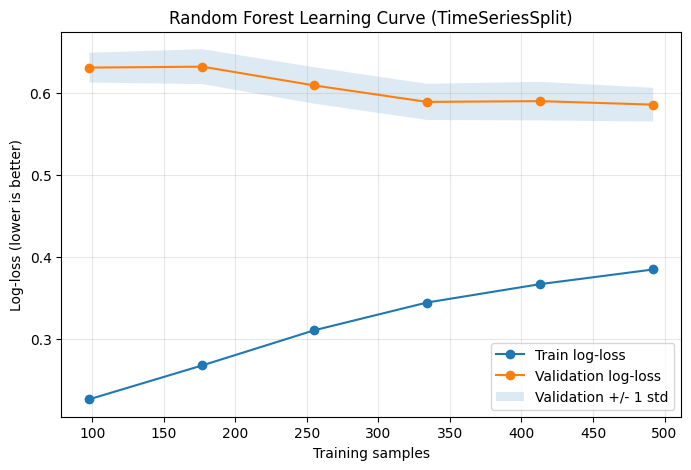

In [38]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Learning curve with time-series splits to inspect bias/variance vs training size
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=tscv,
    scoring="neg_log_loss",
    n_jobs=-1,
    shuffle=False,
    error_score="raise",
)

train_log_loss = -train_scores
val_log_loss = -val_scores

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_log_loss.mean(axis=1), marker="o", label="Train log-loss")
plt.plot(train_sizes, val_log_loss.mean(axis=1), marker="o", label="Validation log-loss")
plt.fill_between(
    train_sizes,
    val_log_loss.mean(axis=1) - val_log_loss.std(axis=1),
    val_log_loss.mean(axis=1) + val_log_loss.std(axis=1),
    alpha=0.15,
    label="Validation +/- 1 std",
)
plt.xlabel("Training samples")
plt.ylabel("Log-loss (lower is better)")
plt.title("Random Forest Learning Curve (TimeSeriesSplit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [43]:
from sklearn.model_selection import cross_validate

# Time-series CV validation on the training window using the tuned model
cv_scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=tscv,
    scoring=cv_scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise",
)

for metric in ["accuracy", "f1", "roc_auc", "neg_log_loss"]:
    test_key = f"test_{metric}"
    train_key = f"train_{metric}"
    test_mean = cv_results[test_key].mean()
    test_std = cv_results[test_key].std()
    train_mean = cv_results[train_key].mean()
    if metric == "neg_log_loss":
        # Convert from negative log-loss back to regular log-loss for readability
        print(
            f"{metric}: train={-train_mean:.4f} | val={-test_mean:.4f} (+/- {test_std:.4f})"
        )
    else:
        print(
            f"{metric}: train={train_mean:.4f} | val={test_mean:.4f} (+/- {test_std:.4f})"
        )

accuracy: train=0.8044 | val=0.7078 (+/- 0.0303)
f1: train=0.8263 | val=0.7338 (+/- 0.0271)
roc_auc: train=0.8917 | val=0.7716 (+/- 0.0422)
neg_log_loss: train=0.4597 | val=0.5735 (+/- 0.0256)
